In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv('crime_train.csv')
test = pd.read_csv('crime_test.csv')
print('Train shape:', train.shape)
print('Test shape:', test.shape)

Train shape: (22489, 12)
Test shape: (9639, 12)


In [4]:
y = train['closed'].map({'Yes': 1, 'No': 0}).values.reshape(-1, 1)

train = train.drop(columns=['closed'])

train = train.select_dtypes(include=[np.number])
test = test.select_dtypes(include=[np.number])

train = train.fillna(train.mean(numeric_only=True))
test = test.fillna(train.mean(numeric_only=True))

X = (train - train.mean()) / train.std()
X_test = (test - train.mean()) / train.std()

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)


Feature matrix shape: (22489, 5)
Target shape: (22489, 1)


In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b):
    m = X.shape[0]
    z = np.dot(X, w) + b
    h = sigmoid(z)
    cost = -(1/m) * np.sum(y * np.log(h + 1e-8) + (1 - y) * np.log(1 - h + 1e-8))
    return cost

def gradient_descent(X, y, w, b, lr, epochs):
    m = X.shape[0]
    cost_list = []

    for i in range(epochs):
        z = np.dot(X, w) + b
        h = sigmoid(z)
        dw = (1/m) * np.dot(X.T, (h - y))
        db = (1/m) * np.sum(h - y)

        w -= lr * dw
        b -= lr * db

        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            cost_list.append(cost)
            print(f"Epoch {i}: Cost = {cost:.4f}")
           
    return w, b, cost_list


Epoch 0: Cost = 0.6931
Epoch 100: Cost = 0.6931
Epoch 200: Cost = 0.6931
Epoch 300: Cost = 0.6931
Epoch 400: Cost = 0.6931
Epoch 500: Cost = 0.6931
Epoch 600: Cost = 0.6931
Epoch 700: Cost = 0.6931
Epoch 800: Cost = 0.6931
Epoch 900: Cost = 0.6931
Epoch 1000: Cost = 0.6931
Epoch 1100: Cost = 0.6931
Epoch 1200: Cost = 0.6931
Epoch 1300: Cost = 0.6931
Epoch 1400: Cost = 0.6931
Epoch 1500: Cost = 0.6931
Epoch 1600: Cost = 0.6931
Epoch 1700: Cost = 0.6931
Epoch 1800: Cost = 0.6931
Epoch 1900: Cost = 0.6931


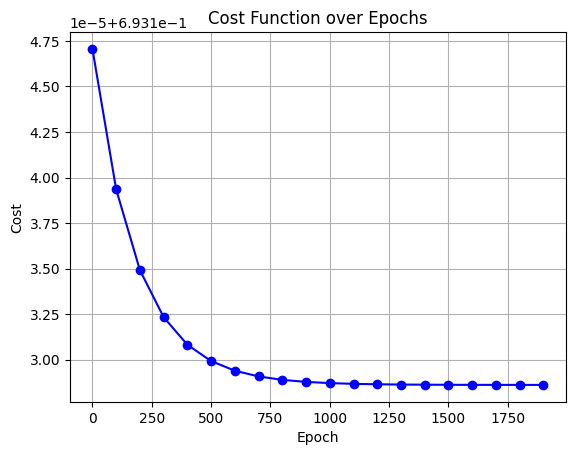

In [6]:
np.random.seed(42)
w = np.zeros((X.shape[1], 1))
b = 0
lr = 0.01
epochs = 2000

w, b, cost_list = gradient_descent(X, y, w, b, lr, epochs)

plt.plot(np.arange(0, epochs, 100), cost_list, marker='o', color='blue')
plt.title('Cost Function over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


In [7]:
def predict(X, w, b):
    probs = sigmoid(np.dot(X, w) + b)
    preds = (probs >= 0.5).astype(int)
    return preds, probs

In [8]:
y_train_pred, y_train_prob = predict(X, w, b)
y_test_pred, y_test_prob = predict(X_test, w, b)

acc = np.mean(y_train_pred == y) * 100
print(f'Training Accuracy: {acc:.2f}%')

Training Accuracy: 50.45%
